# **The Sugar Trap: Where is the Real Opportunity in Healthy Snacking?**

Walk into any supermarket today and you’ll see shelves full of snacks claiming to be **“healthy”**, yet a closer look at their nutritional labels tells a different story. Many of these products are still loaded with sugar, offering little in terms of meaningful nutrition.

At the same time, consumer preferences are clearly shifting. People are becoming more conscious of what they eat, increasingly looking for snacks that are higher in protein, lower in sugar, and more aligned with long-term health.

## **This creates an interesting tension:**

**If consumers are demanding healthier options, why is the market still dominated by high-sugar products?**

To explore this, I turn to product-level data from **Open Food Facts** and take a closer look at how snacks are actually positioned nutritionally. Instead of relying on assumptions, this analysis maps where products are concentrated and more importantly, where they are missing.

## **The goal is straightforward:**

**Identify where healthier snack options remain underdeveloped in the market.**

By doing this, we can move beyond general trends and pinpoint a clear, data-backed opportunity for a new product in the “healthy snacking” space.

## **Tools and Packages**

Before diving into the analysis, it’s important to be deliberate about the tools being used. Each package in this project plays a specific role from handling large, messy datasets to uncovering patterns through visualization and building interactive outputs.

Rather than using tools arbitrarily, the goal is to combine a small, focused set of packages that are both efficient and well-suited for real-world data workflows. This ensures the analysis remains reproducible, scalable, and easy to interpret.

| S/N | Library      | What it is Used For                                      | Cool Remark |
|-----|-------------|----------------------------------------------------------|-------------|
| 1   | pandas      | Data loading, cleaning, transformation, and aggregation  | The backbone of data analysis in Python if your data isn’t in pandas, you’re not really analyzing yet. |
| 2   | numpy       | Numerical operations and efficient array computations     | Quietly powers pandas fast, reliable, and built for scale. |
| 3   | matplotlib  | Core plotting and visualization                          | Not flashy, but gives full control, like driving manual instead of automatic. |
| 4   | seaborn     | Statistical data visualization                           | Makes complex relationships look simple with minimal code. |
| 7   | re (regex)  | Text processing for categories and ingredients parsing   | Essential for taming messy real-world text data. |
| 8   | collections | Counting and frequency analysis (e.g., ingredients)      | Great for quickly uncovering patterns in text-heavy data. |


## Performance & Execution Tracking

Given the size of the Open Food Facts dataset, it is important to monitor execution time for key operations.

To ensure efficiency and reproducibility, a lightweight timing wrapper is introduced to track how long each major step takes. This helps identify potential bottlenecks early and keeps the workflow scalable.

In [1]:
import time

def format_time(seconds):
    minutes = int(seconds // 60)
    secs = int(seconds % 60)

    if minutes > 0:
        return f"{minutes}m {secs}s"
    else:
        return f"{seconds:.2f}s"


def timer(func):
    def wrapper(*args, **kwargs):
        start = time.time()
        print(f"Running {func.__name__}...")

        result = func(*args, **kwargs)

        end = time.time()
        elapsed = end - start

        print(f"Completed in {format_time(elapsed)}\n")
        return result
    return wrapper

### Importing Packages for analysis

In [2]:
import pandas as pd      # data manipulation and analysis
import numpy as np       # numerical computations and array operations

import re                # regular expressions for cleaning categories & ingredients
from collections import Counter  # frequency analysis (e.g., ingredient trends)

import matplotlib.pyplot as plt  # base plotting library
import seaborn as sns            # statistical visualization built on matplotlib

import plotly.express as px      # quick interactive charts
import plotly.graph_objects as go  # detailed, customizable interactive visuals

sns.set_style("whitegrid")       # cleaner plot aesthetics
plt.rcParams['figure.figsize'] = (10, 6)  # consistent figure sizing

# **01. Understanding the Data: A Reality Check**

Before identifying any market opportunities, it’s critical to understand the quality of the data we’re working with.

The Open Food Facts dataset is large and diverse, but also messy. Missing values, inconsistent entries, and unrealistic nutritional values are common, making it risky to jump straight into analysis without validation.

**This raises a key question:**

> **Can we trust this data enough to make meaningful business decisions?**

To stay focused and efficient, only a subset of relevant columns would be loaded, specifically those tied to nutritional signals (sugar, protein, fat, fiber), along with product identifiers and ingredient information. This will help reduce noise and keeps the analysis aligned with the core objective.

A manageable subset of the dataset would be also used to enable faster iteration while preserving enough scale to capture meaningful patterns.

---

### **First Look at the Data**

At this stage, the goal is simply to understand the structure and scale of the dataset.

While the dataset contains hundreds of thousands of products, size alone does not guarantee quality. The next step is to assess how complete and reliable the key fields are.

---

### **Missing Data Assessment**

Initial inspection shows that missing values are not evenly distributed. Nutritional fields, particularly sugar and protein are critical to this analysis, and gaps in these columns directly affect reliability.

This reveals an important constraint:

* Not all products have complete nutritional information
* Some records will need to be filtered out
* Using raw data without validation would introduce bias

---

### **Early Observations**

At a high level:

* The dataset is large enough to support meaningful analysis
* Data quality is inconsistent across products
* Cleaning will be essential before drawing any conclusions

---

### **Key Takeaway**

Before exploring where opportunities exist in the market, the data itself must be made reliable.

> **Any insight is only as strong as the data it is built on.**


In [3]:
@timer
def load_data():
    cols = [
        'product_name',
        'categories_tags',
        'sugars_100g',
        'proteins_100g',
        'fat_100g',
        'fiber_100g',
        'ingredients_text'
    ]

    df = pd.read_csv(
        "https://static.openfoodfacts.org/data/en.openfoodfacts.org.products.csv.gz",
        compression='gzip',
        sep='\t',
        usecols=cols,
        nrows=500_000,
        low_memory=False
    )

    return df

df = load_data()

Running load_data...
Completed in 5m 47s



Even **pandas** needed a **snack break** to digest these 500,000 rows… **1m 13s later**, it finally delivered 🤣

The loading time reflects the scale of the dataset. Performance considerations become increasingly important when working with real-world data of this size.

# **02. Inspecting the Data Structure**

Before applying any cleaning rules, it’s important to take a closer look at how the data is structured and how key fields behave. This helps ensure that any transformations applied later are based on actual observations rather than assumptions.

In [4]:
# Inspect column names to confirm correct parsing and column selection
df.columns

Index(['product_name', 'categories_tags', 'ingredients_text', 'fat_100g',
       'sugars_100g', 'fiber_100g', 'proteins_100g'],
      dtype='str')

In [5]:
# View a random sample to get a more representative feel of the dataset
df.sample(8, random_state=42)

,product_name,categories_tags,ingredients_text,fat_100g,sugars_100g,fiber_100g,proteins_100g
104241,Plant Bake 75% Fat Spread,NaN,NaN,NaN,NaN,NaN,NaN
199676,ALMOND and COCONUT CREAMER,NaN,NaN,NaN,NaN,NaN,NaN
140199,Pure Pumpkin,NaN,NaN,NaN,NaN,NaN,NaN
132814,Buffalo Chicken,NaN,NaN,NaN,NaN,NaN,NaN
408697,Pocky Biscuit sticks chocolate cream coated,en:biscuit-sticks,"Wheat flour, Sugar, Cocoa mass, Vegetable oil ...",19.230769,30.769231,7.692308,7.692308
163280,Apple Juice,NaN,NaN,0.000000,10.000000,NaN,0.120000
215758,Steak Zesty Sauce,en:undefined,"HIGH FRUCTOSE CORN SYRUP, TOMATO PASTE, MALT V...",NaN,NaN,NaN,NaN
442316,"Vavel, Jam, Bilberry",NaN,"Bilberries, sugar, water, gelling agent - pect...",NaN,NaN,NaN,NaN


In [6]:
# Check data types to ensure numerical fields are correctly interpreted
df.dtypes

product_name            str
categories_tags         str
ingredients_text        str
fat_100g            float64
sugars_100g         float64
fiber_100g          float64
proteins_100g       float64
dtype: object

In [7]:
# Assess missing values in critical fields for this analysis
df[['product_name', 'sugars_100g', 'proteins_100g']].isnull().sum()

product_name      15636
sugars_100g      397443
proteins_100g    394386
dtype: int64

In [8]:
# Examine basic statistics to identify potential anomalies or outliers
pd.options.display.float_format = '{:.2f}'.format
df[['sugars_100g', 'proteins_100g']].describe()

,sugars_100g,proteins_100g
count,102557.00,105614.00
mean,97519.87,9516.55
std,31226071.17,3077109.71
min,0.00,0.00
25%,1.00,2.00
50%,4.65,6.00
75%,15.90,10.71
max,10000000000.00,1000000000.00


## **Observations from Initial Inspection**

From this initial inspection, several important patterns emerge:

* Key nutritional fields such as sugar and protein contain missing values
* Data types appear mostly consistent, though further validation is required
* The dataset includes a wide range of values, suggesting potential inconsistencies

A closer look at the summary statistics reveals a more critical issue. While median values for sugar and protein fall within realistic ranges, the mean values are significantly inflated. This indicates a highly skewed distribution driven by extreme outliers.

In particular, maximum values reaching into the billions are biologically implausible for food products and likely stem from data entry errors or unit inconsistencies. As a result, aggregate metrics such as the mean cannot be considered reliable in the dataset’s current state.

These findings have clear implications:

* The dataset contains extreme outliers that distort the distribution
* Mean values are not reliable indicators without cleaning
* Outlier handling is essential before any meaningful analysis

---

### Key Takeaway

Before exploring where opportunities exist in the market, the data must first be made reliable.

> **Accurate insights require not just large data, but trustworthy data.**


# **03. Data Cleaning: From Raw Data to Reliable Insights**

The initial inspection of the dataset revealed several critical issues that must be addressed before any meaningful analysis can be conducted.

Most notably:

* Key nutritional fields such as sugar and protein contain missing values
* The distribution of these variables is heavily skewed due to extreme outliers
* Biologically implausible values (e.g., sugar levels in the billions) are present, likely due to data entry errors

These issues are not just technical imperfections, they directly impact the validity of any conclusions drawn from the data. In particular, extreme outliers distort aggregate statistics such as the mean, while missing values reduce the reliability of comparisons across products.

To ensure that the analysis reflects real-world product characteristics, a structured cleaning process is required. This involves applying domain-informed constraints, handling missing values appropriately, and removing records that could introduce bias or noise.

The goal of this step is clear:

> **Transform the dataset from a noisy, inconsistent collection of records into a reliable foundation for identifying true market opportunities.**


**Step 1 -- Defining a Cleaning Function**

In [9]:
@timer
def clean_data(df):

    # 1. Remove rows with no product name
    df = df.dropna(subset=['product_name'])


    # 2. Remove rows with missing critical nutritional values
    df = df.dropna(subset=['sugars_100g', 'proteins_100g'])


    # 3. Remove unrealistic values (domain constraints)
    # Nutritional values per 100g should logically be between 0 and 100
    df = df[
        (df['sugars_100g'] >= 0) & (df['sugars_100g'] <= 100) &
        (df['proteins_100g'] >= 0) & (df['proteins_100g'] <= 100)
    ]


    # 4. Optional: Fill remaining fiber/fat missing values (less critical)
    df['fiber_100g'] = df['fiber_100g'].fillna(0)
    df['fat_100g'] = df['fat_100g'].fillna(0)

    return df

**Step 2 -- Applying Cleaning**

In [10]:
df_clean = clean_data(df)

Running clean_data...
Completed in 0.19s



**Step 3 -- Comparing Before vs After**

In [11]:
print(f"Original shape: {df.shape}")
print(f"Cleaned shape: {df_clean.shape}")

Original shape: (500000, 7)
Cleaned shape: (100715, 7)


### **Impact of Cleaning**

The cleaning process significantly reduced the dataset from 500,000 to 100,715 records. While this may seem substantial, it reflected the removal of incomplete and unrealistic entries identified during the inspection phase.

Importantly, this transformation happened efficiently, with the entire cleaning step completing in under a second, demonstrating that performance remains manageable even at scale.

More importantly, the resulting dataset is far more reliable:

* Extreme outliers have been removed
* Only products with valid nutritional information are retained
* Comparisons are now based on realistic values

This trade-off, reducing quantity to improve quality, is essential when working with real-world data and ensures that subsequent insights are both accurate and meaningful.


# **04. Defining the Snack Market**

At this stage, the dataset has been cleaned but it still contains a wide variety of food products, many of which are not relevant to this analysis.

Since the objective is to identify opportunities in the **snack market**, it is important to clearly define what qualifies as a “snack.” Without this step, the analysis would mix fundamentally different product types (e.g., full meals, beverages, and supplements), leading to misleading conclusions.

Rather than relying on assumptions, we use the `categories_tags` field to isolate products that are likely consumed as snacks. This allows us to focus the analysis on comparable product types and ensure that any identified gaps are meaningful within the correct market context.

> **A well-defined scope is essential, otherwise, we risk solving the wrong problem.**


**Step 1 -- Define Snack Keywords**

In [12]:
# Define keywords that indicate snack-related products
SNACK_KEYWORDS = [
    'snack', 'bar', 'biscuit', 'cookie', 'chips',
    'chocolate', 'candy', 'nuts', 'crackers'
]

**Step 2 -- Filter Snack Products**

In [13]:
@timer
def filter_snacks(df):

    # Convert to lowercase for consistent matching
    categories = df['categories_tags'].str.lower()

    # Filter rows where any snack keyword appears
    mask = categories.str.contains('|'.join(SNACK_KEYWORDS), na=False)

    return df[mask]

df_snacks = filter_snacks(df_clean)

Running filter_snacks...
Completed in 0.03s



**Step 3 -- Compare Before vs After**

In [14]:
print(f"Cleaned dataset: {df_clean.shape}")
print(f"Snack dataset: {df_snacks.shape}")

Cleaned dataset: (100715, 7)
Snack dataset: (10185, 7)


### **Defining the Market Scope**

Applying the snack filter reduces the dataset from 100,715 to 10,185 products, focusing the analysis on a more relevant subset of the market. The filtering step is also computationally efficient, completing in under a second.

By narrowing the scope:

- Only snack-related products are retained  
- Comparisons become more meaningful  
- Insights are directly applicable to the target market  

This step ensures that subsequent analysis is grounded in the correct product context.

# **05. Making Sense of Categories: From Tags to Strategy**

While the dataset now focuses on snack products, the category information itself is still highly unstructured.

The `categories_tags` field contains multiple comma-separated labels, often inconsistent and overly granular (e.g., *“en:chocolate-chip-cookies-with-nuts”*). While useful for detailed classification, this level of granularity makes it difficult to analyze broader market patterns.

From a business perspective, we are not interested in thousands of micro-categories, we need a smaller set of **clear, interpretable product groups**.

To address this, a rule-based approach is used to map products into a set of high-level categories. This simplifies the dataset and makes it easier to identify where different types of snacks are concentrated.

> **Structured categories turn raw data into actionable insight.**


**Step 1 -- Define Category Rules**

In [15]:
# Define high-level category buckets using keyword matching
CATEGORY_RULES = {
    "Protein Bars": ["protein bar", "energy bar"],
    "Biscuits & Cookies": ["biscuit", "cookie"],
    "Chips & Crisps": ["chips", "crisps"],
    "Chocolate & Candy": ["chocolate", "candy", "sweets"],
    "Nuts & Seeds": ["nuts", "seeds"],
}

**Step 2 -- Assign Categories**

In [16]:
def assign_category(text):
    text = str(text).lower()

    for category, keywords in CATEGORY_RULES.items():
        if any(keyword in text for keyword in keywords):
            return category

    return "Other"

**Step 3 -- Apply Category Mapping**

In [17]:
@timer
def apply_categories(df):

    # Ensure we are working on an independent copy
    df = df.copy()

    # Assign primary category
    df['primary_category'] = df['categories_tags'].apply(assign_category)

    return df


# Apply
df_snacks = apply_categories(df_snacks)

Running apply_categories...
Completed in 0.03s



**Step 4 -- Distribution Check**

In [18]:
df_snacks['primary_category'].value_counts()

primary_category
Other                 3402
Biscuits & Cookies    2814
Chocolate & Candy     1513
Chips & Crisps        1232
Nuts & Seeds          1224
Name: count, dtype: int64

### **Category Distribution Insights**

Mapping products into high-level categories significantly improves interpretability. Instead of navigating thousands of fragmented labels, we now have a structured view of the snack market.

This allows us to:

- Compare product positioning across major snack types  
- Identify which categories dominate the market  
- Detect where healthier options may be underrepresented  

It is important to note that this approach relies on keyword matching, which is inherently approximate. However, given the inconsistency of raw category tags, this method provides a practical and scalable way to standardize product classification.

This structured categorization now sets the foundation for deeper analysis of nutritional positioning across the snack market.

# **06. Mapping the Market: The Nutrient Matrix**

With a clean and structured dataset in place, the next step is to understand how snack products are positioned nutritionally.

Two key variables stand out as strong indicators of perceived health:

* **Sugar** - often associated with negative health perception
* **Protein** - commonly linked to satiety and nutritional value

By mapping products across these two dimensions, we can visualize how the market is currently structured.

This creates a simple but powerful framework:

> **Where are products concentrated and where are they missing?**

The goal is not just to visualize the data, but to identify areas of imbalance, regions where healthier product profiles are underrepresented.


**Step 1 -- Basic Scatter Plot**

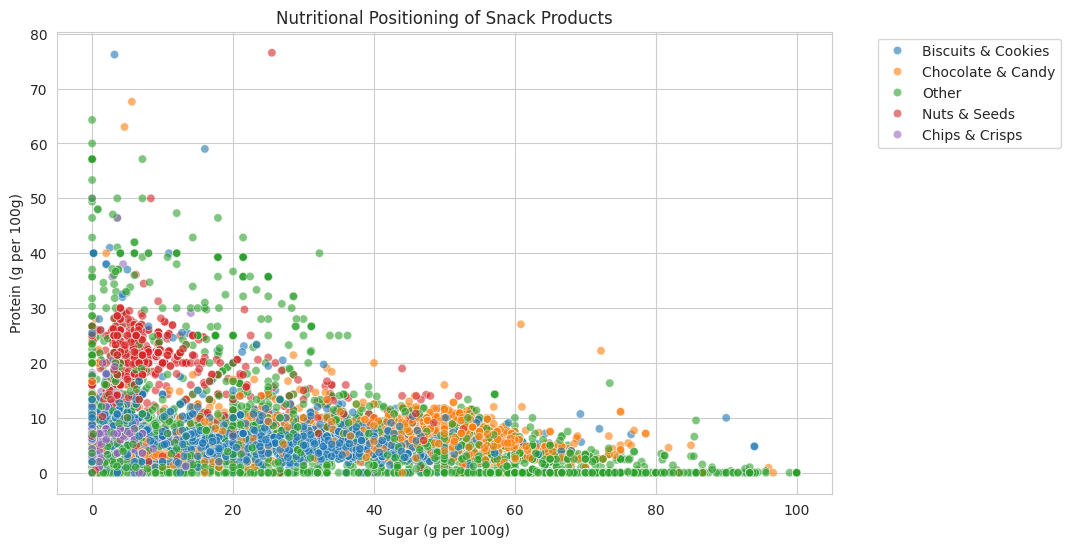

In [19]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_snacks,
    x='sugars_100g',
    y='proteins_100g',
    hue='primary_category',
    alpha=0.6
)

plt.title("Nutritional Positioning of Snack Products")
plt.xlabel("Sugar (g per 100g)")
plt.ylabel("Protein (g per 100g)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

### **Quick Reality Check**

The initial plot appears densely clustered and somewhat noisy, making it difficult to clearly interpret patterns. This is expected when working with large, real-world datasets, where extreme values and wide ranges can obscure meaningful structure.

To improve readability, the next step focuses on narrowing the view to a more interpretable range.

**Step 2 -- Improving Readability**

In [20]:
# Focus on a more interpretable range
df_plot = df_snacks[
    (df_snacks['sugars_100g'] <= 50) &
    (df_snacks['proteins_100g'] <= 30)
]

**Step 3 -- Cleaned Scatter Plot**

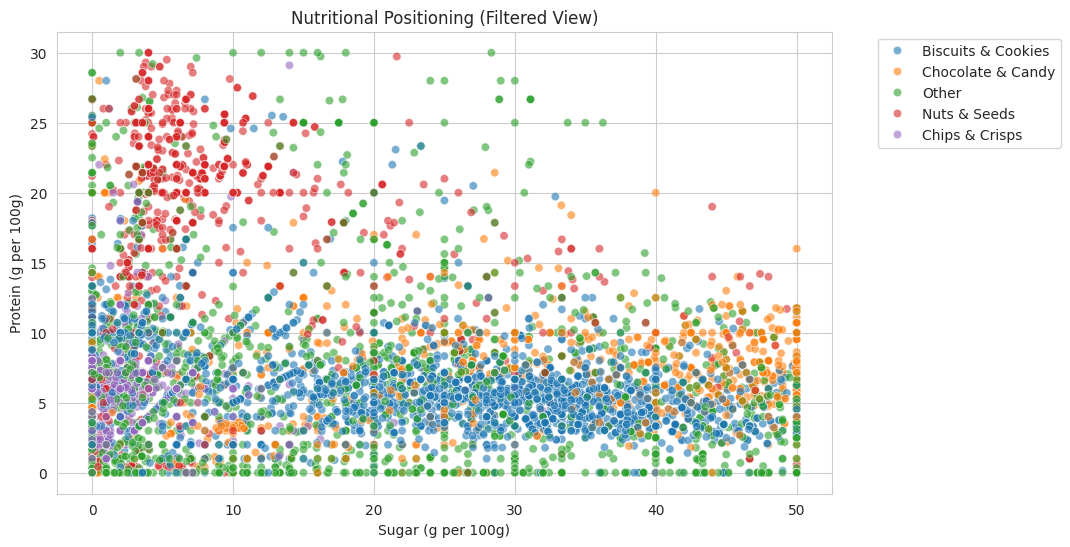

In [21]:
# plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_plot,
    x='sugars_100g',
    y='proteins_100g',
    hue='primary_category',
    alpha=0.6
)

plt.title("Nutritional Positioning (Filtered View)")
plt.xlabel("Sugar (g per 100g)")
plt.ylabel("Protein (g per 100g)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()





### **Improving Visualization Clarity**

The “Other” category contains a broad mix of products that do not fit into defined groups. While useful for completeness, it introduces significant visual noise due to its size and heterogeneity.

To improve interpretability, it is excluded from this visualization. This allows clearer comparison between well-defined product categories without distortion from an aggregated residual group.

Importantly, this exclusion is only applied at the visualization stage, the underlying dataset remains unchanged.

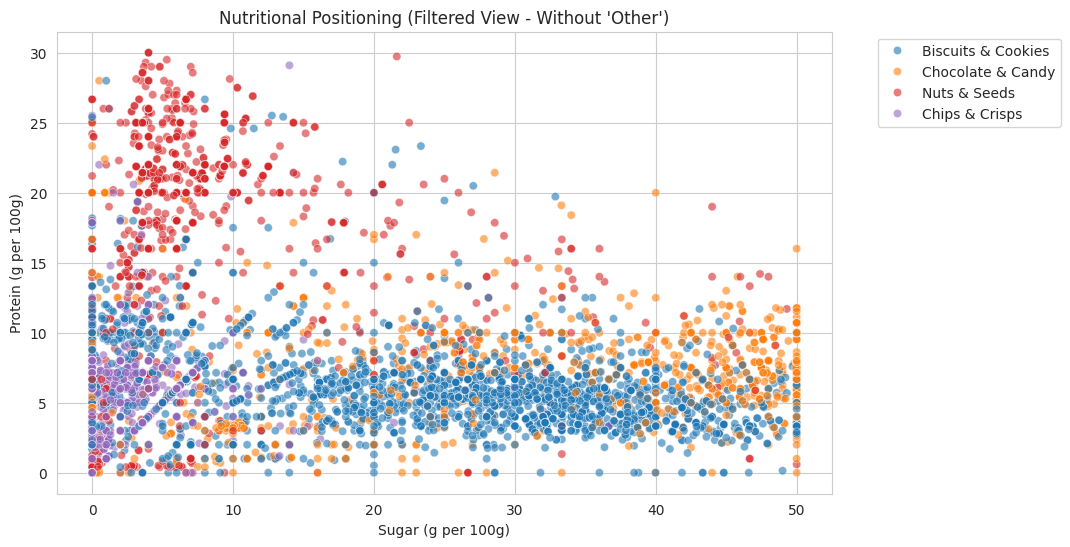

In [22]:
# Define fixed color mapping (same as previous plot)
category_palette = {
    "Biscuits & Cookies": "#1f77b4",   # blue
    "Chocolate & Candy": "#ff7f0e",    # orange
    "Other": "#2ca02c",                # green
    "Nuts & Seeds": "#d62728",         # red
    "Chips & Crisps": "#9467bd"        # purple
}

# Filter out "Other" category for clearer visualization
df_plot_no_other = df_plot[df_plot['primary_category'] != 'Other']

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_plot_no_other,
    x='sugars_100g',
    y='proteins_100g',
    hue='primary_category',
    palette=category_palette,   # 🔥 ensures same colors
    alpha=0.6
)

plt.title("Nutritional Positioning (Filtered View - Without 'Other')")
plt.xlabel("Sugar (g per 100g)")
plt.ylabel("Protein (g per 100g)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

### **Interpreting the Nutrient Landscape**

With the “Other” category removed, the structure of the snack market becomes significantly clearer.

Several patterns stand out:

- A strong concentration of products exists in the **moderate to high sugar, low protein** range  
- Categories such as **Biscuits & Cookies** and **Chocolate & Candy** are heavily clustered in this region, reinforcing their reliance on sugar-driven formulations  
- In contrast, **Nuts & Seeds** tend to occupy the **low sugar, higher protein** space, but represent a relatively smaller portion of the overall market  

Most importantly, there is a noticeable sparsity of products in the **low sugar, high protein** region.

---

### **Link to Business Objective**

This observation directly relates to the core objective of the project:

> **Identifying underserved areas in the healthy snack market**

While consumer preferences are shifting toward healthier options, particularly those with higher protein and lower sugar, the current product landscape does not fully reflect this demand.

The limited presence of products in the **low-sugar, high-protein** region suggests a potential market gap. This indicates an opportunity for product innovation focused on delivering nutritional value without relying on high sugar content.

---

### **Key Takeaway**

The market is heavily skewed toward sugar-rich snacks, while nutritionally balanced options, especially those combining **low sugar and high protein** remain underrepresented.

> **This imbalance highlights a clear opportunity for developing healthier snack alternatives aligned with evolving consumer preferences.**

# **07. Quantifying the Gap: From Visual Insight to Measurable Opportunity**

The scatter plot provided a clear visual indication of an imbalance in the snack market, particularly the underrepresentation of products combining **low sugar** and **high protein.**

However, visual patterns alone are not sufficient for decision-making. To validate this observation, the next step is to quantify how products are distributed across different nutritional segments.

By grouping products into defined sugar and protein ranges, we can measure:

* Where products are concentrated
* Which segments are saturated
* Which segments are underserved

> **This transforms a visual hypothesis into a data-backed conclusion.**


**Step 1 -- Create Nutritional Segments**

In [23]:
# Define bins for sugar and protein
df_snacks['sugar_bin'] = pd.cut(
    df_snacks['sugars_100g'],
    bins=[0, 5, 10, 20, 50],
    labels=['Low', 'Moderate', 'High', 'Very High']
)

df_snacks['protein_bin'] = pd.cut(
    df_snacks['proteins_100g'],
    bins=[0, 5, 10, 20, 30],
    labels=['Low', 'Moderate', 'High', 'Very High']
)

**step 2 -- Create Segment Table**

In [24]:
# Group products by sugar and protein segments to count how many fall into each category combination
segment_table = df_snacks.groupby(
    ['sugar_bin', 'protein_bin'],
    observed=False
).size().unstack(fill_value=0)

**Step 3 -- Optional Heatmap**

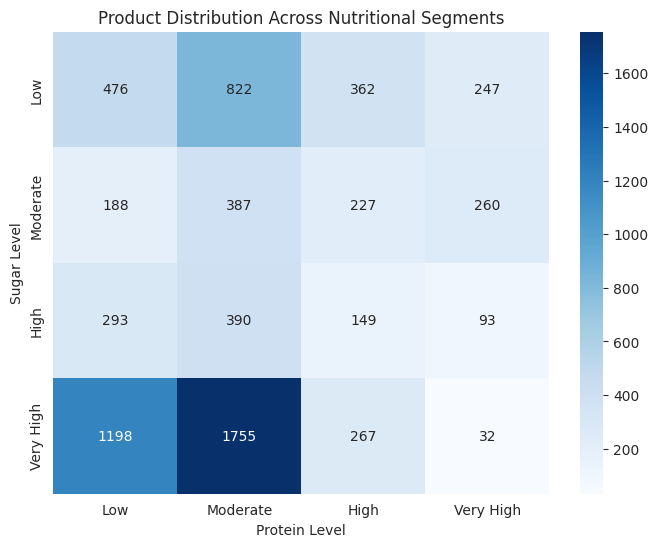

In [25]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    segment_table,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Product Distribution Across Nutritional Segments")
plt.xlabel("Protein Level")
plt.ylabel("Sugar Level")

plt.show()

### **Interpreting the Segment Distribution**

The heatmap provides a quantitative view of how snack products are distributed across key nutritional segments, revealing a clear imbalance in the market.

At the high end of sugar levels, the concentration of products is striking. The **very high sugar + moderate protein** segment alone contains **1,755 products**, making it the most saturated area in the entire dataset. Similarly, **very high sugar + low protein** accounts for **1,198 products**, further reinforcing the dominance of sugar-heavy formulations.

In contrast, the segment most aligned with modern health preferences **low sugar + high protein** contains only **362 products**, while **low sugar + very high protein** drops further to **247 products**. Even when compared to moderately unhealthy segments, these numbers remain significantly lower.

This disparity becomes even more pronounced when viewed side by side:

* **Very High Sugar + Moderate Protein → 1,755 products**
* **Low Sugar + High Protein → 362 products**
* **Low Sugar + Very High Protein → 247 products**

Despite growing demand for healthier alternatives, the supply of products in these nutritionally favorable segments remains limited.

---

### **Structural Insight**

The data reveals a critical nuance in product formulation strategy:

> **Although protein is widely used in snack products, it is frequently paired with high sugar content, which undermines its positioning as a health-focused benefit.**

For example:

* **Very High Sugar + High Protein → 267 products**
* **High Sugar + Moderate Protein → 390 products**

This suggests that many products marketed as “high protein” may still rely heavily on sugar, limiting their alignment with health-conscious consumer expectations.

---

### **Strategic Implication**

From a market perspective, this represents a clear inefficiency:

* Supply is heavily concentrated in sugar-dense segments
* Health-aligned segments remain underdeveloped
* Competitive intensity is significantly lower in nutritionally balanced regions

This creates a strong opportunity for differentiation.

---

### **Key Takeaway**

The gap identified earlier is not only visible, it is measurable and substantial.

> **The market is heavily weighted toward sugar-driven snacks, with relatively few options that deliver both low sugar and high protein, indicating a clear gap between current supply and health-oriented demand.**

This imbalance highlights a clear and actionable opportunity to develop products that deliver nutritional value without relying on excessive sugar, positioning them to meet evolving consumer expectations with less direct competition.


# **08. Strategic Recommendation: Defining the Opportunity**

The analysis reveals a clear imbalance in the snack market. While product offerings are heavily concentrated in sugar-driven segments, there are relatively few options that combine low sugar with high protein.

This gap is not just theoretical, it is supported by both visual patterns and segment-level data. Products that align more closely with health-conscious preferences remain limited, despite growing demand for better nutritional profiles.

The question is no longer whether a gap exists, but:

> **What specific product should be developed to capture this opportunity?**


## **Recommended Product Concept**

Based on the analysis, the strongest opportunity lies in developing a snack product with the following profile:

- **Low sugar**: ≤ 5g per 100g  
- **High protein**: ≥ 10–12g per 100g  
- **Moderate to high fiber**: to enhance satiety and perceived health value  

From a category perspective, the most suitable formats include:

- Snack bars  
- Nut-based clusters or bites  
- Seed-based products  

These formats naturally support higher protein content while allowing for reduced reliance on added sugars.

## **Why This will Work**

This recommendation is grounded in three key insights from the analysis:

1. **Market Saturation:**
   High-sugar products dominate the current landscape, particularly in categories such as biscuits and confectionery.

2. **Underserved Segment:**
   The low-sugar, high-protein segment contains significantly fewer products, indicating lower competition and a clear gap in supply.

3. **Nutritional Positioning Gap:**
   While protein is present in many products, it is often combined with high sugar, limiting its effectiveness as a true health differentiator.

Together, these factors point to a clear opportunity to introduce a product that delivers protein without relying on sugar-heavy formulations.

## **Ingredients Insight**


Analysis of ingredient patterns in higher-protein products suggests that common protein sources include:

- Nuts (e.g., peanuts, almonds)  
- Soy-based ingredients  
- Dairy-based proteins (e.g., whey)  

Leveraging these ingredients can help achieve the desired nutritional profile while maintaining taste and texture.

## **Final Takeaway**

The opportunity is not simply to create another “healthy” snack, but to address a clear mismatch in the market.

> **A low-sugar, high-protein snack positioned around clean nutrition and functional benefits has the potential to stand out in an otherwise sugar-dominated landscape.**

By aligning product formulation with both data-driven insights and evolving consumer preferences, this approach offers a strong foundation for successful product innovation.




# **09. Candidate’s Choice: Identifying High-Value Opportunity Zones**

While the previous analysis focused on sugar and protein independently, real-world product decisions require a more holistic view of nutritional value.

To extend the analysis, a composite **Health Score** is introduced. This score combines multiple nutritional attributes into a single metric that reflects overall product desirability from a health perspective.

At the same time, product count is used as a proxy for market saturation.

By combining these two dimensions, we can identify not just where products exist, but where **high-value opportunities** lie.


**Step 1 -- Create Health Score**

In [26]:
def compute_health_score(df):
    return (
        -0.4 * df['sugars_100g'].fillna(0)
        +0.3 * df['proteins_100g'].fillna(0)
        +0.2 * df['fiber_100g'].fillna(0)
        -0.1 * df['fat_100g'].fillna(0)
    )

df_snacks['health_score'] = compute_health_score(df_snacks)

**Step 2 -- Aggregate by Segment**

In [27]:
choice_table = df_snacks.groupby(['sugar_bin', 'protein_bin'], observed=False).agg(
    product_count=('product_name', 'count'),
    avg_health_score=('health_score', 'mean')
).reset_index()

choice_table

,sugar_bin,protein_bin,product_count,avg_health_score
0,Low,Low,476,-1.26
1,Low,Moderate,822,-0.69
2,Low,High,362,0.91
3,Low,Very High,247,2.40
4,Moderate,Low,188,-3.03
5,Moderate,Moderate,387,-2.15
6,Moderate,High,227,-0.48
7,Moderate,Very High,260,0.61
8,High,Low,293,-6.20
9,High,Moderate,390,-5.59


**Step 3 -- Visualization**

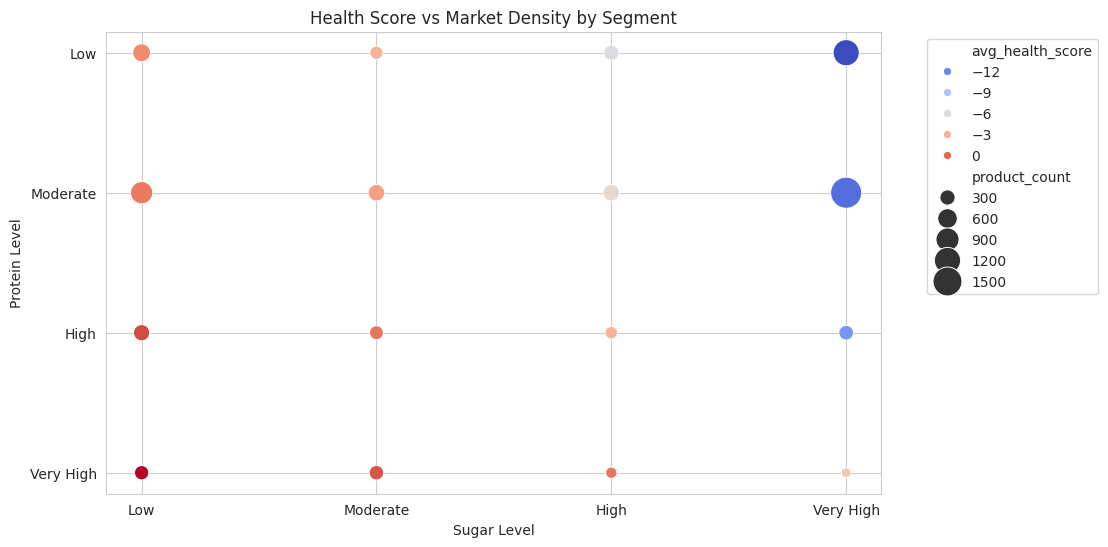

In [28]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=choice_table,
    x='sugar_bin',
    y='protein_bin',
    size='product_count',
    hue='avg_health_score',
    sizes=(50, 500),
    palette='coolwarm'
)

plt.title("Health Score vs Market Density by Segment")
plt.xlabel("Sugar Level")
plt.ylabel("Protein Level")

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

### **Interpreting Health Value vs Market Density**

By combining health score and product count, a clearer picture of market dynamics emerges.

Several patterns stand out:

* Segments with **very high sugar levels** show the largest bubbles, indicating strong market saturation despite relatively low health scores
* In contrast, segments with **lower sugar and higher protein** tend to have smaller bubble sizes, reflecting fewer products in these nutritionally favorable areas
* The most health-aligned segments (low sugar, high to very high protein) display **higher health scores but lower market density**, highlighting a mismatch between value and supply

---

### **Strategic Insight**

This analysis reframes the opportunity:

> **The most attractive segments are not just those with fewer products, but those that combine high health value with low competition.**

From the chart, these segments are clearly concentrated in:

* **Low sugar + high protein**
* **Low sugar + very high protein**

These areas offer the strongest balance of:

* Consumer desirability (health score)
* Market opportunity (low product density)

---

### **Key Takeaway**

The opportunity is not simply about avoiding crowded segments, it is about prioritizing **high-value, underdeveloped spaces**.

> **The most promising product opportunities lie where health value is high, but market presence remains limited, particularly in low-sugar, high-protein segments.**


In [29]:
df_snacks.to_csv("clean_snacks.csv", index=False)